# Movie Recommendation System with Explainability - Final Notebook

## 1. Introduction

Movies are one of the most widely consumed forms of entertainment, and our own interest in cinema was the main motivation for this project. As viewers, we often face the same question that streaming platforms try to answer every day: what should I watch next? With thousands of titles available, manual browsing quickly becomes inefficient. A recommendation system can reduce this search effort by learning user preferences and ranking movies that are likely to be relevant for each person.

The goal of this project is to build a movie recommendation system that can support users with existing rating history as well as users with little or no history. For users with rating history, the system can learn from previous interactions and recommend movies similar to what they liked before. For users without enough history, the system must rely more on general popularity, movie metadata, and content-based signals. This makes the project realistic, because real platforms constantly serve both returning users and new or inactive users.

This problem matters because recommender systems are now central to how people consume media. Streaming platforms have become increasingly popular and have largely replaced traditional television for many viewers. Platforms such as Netflix, Disney+, HBO Max, Amazon Prime Video, and others depend on recommendation systems to keep users engaged, help them discover relevant content, and make large catalogs usable. Building our own recommendation system was therefore both useful and fascinating: it allowed us to recreate, on a smaller scale, a type of machine learning system that is used constantly in real life.

A major challenge in this project is the cold-start problem. New users may not have enough ratings for the system to understand their preferences, while new or rarely rated movies may not have enough interaction data to be recommended confidently. Other important challenges include data sparsity, because each user rates only a small fraction of all available movies; popularity bias, where already popular movies can dominate recommendations; changing user taste over time; and the need to evaluate recommendations as ranked lists rather than only as rating predictions.

Another key requirement is explainability. A recommendation is more useful when the user can understand why it was suggested. For this reason, the project does not only focus on accuracy. It also aims to provide interpretable explanations, such as recommending a movie because it is similar to movies the user liked, because it matches preferred genres, or because it has strong popularity support. The final system combines recommendation quality with explanations that can be shown in a Streamlit application.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\rafal\OneDrive\Dokumente\GitHub\Movie-Recommendation-System-with-Explainability


## 2. Data Loading & Validation

The dataset used in this project comes from the GroupLens MovieLens collection: https://grouplens.org/datasets/movielens/

We selected the MovieLens `latest-small` dataset, which is a 100K-scale movie recommendation dataset. According to the dataset description, it contains approximately 100,000 ratings and 3,600 tag applications applied to around 9,000 movies by around 600 users. The dataset was last updated in September 2018.

The raw data is stored locally in `data/raw/` and consists of four CSV files:

- `ratings.csv`: user-movie ratings and timestamps
- `movies.csv`: movie titles and genre labels
- `tags.csv`: user-generated tag applications
- `links.csv`: external identifiers, such as IMDb and TMDB IDs

Before modeling, we validate that the required files are available, load the raw tables, inspect their basic structure, and check for common data quality issues such as missing values, duplicate interactions, invalid rating ranges, and inconsistent movie identifiers.

In [2]:
required_paths = {
    "raw ratings": PROJECT_ROOT / "data" / "raw" / "ratings.csv",
    "raw movies": PROJECT_ROOT / "data" / "raw" / "movies.csv",
    "raw tags": PROJECT_ROOT / "data" / "raw" / "tags.csv",
    "raw links": PROJECT_ROOT / "data" / "raw" / "links.csv",
    "processed master data": PROJECT_ROOT / "data" / "processed" / "master_data_small.parquet",
    "ranking NeuMF model": PROJECT_ROOT / "models" / "neumf_ranking_model.pth",
    "final top-k summary": PROJECT_ROOT / "reports" / "topk_evaluation_summary.csv",
    "training history": PROJECT_ROOT / "reports" / "neumf_ranking_training_history.csv",
    "Streamlit app": PROJECT_ROOT / "app.py",
}

readiness = pd.DataFrame(
    [
        {"artifact": name, "path": str(path.relative_to(PROJECT_ROOT)), "exists": path.exists()}
        for name, path in required_paths.items()
    ]
)
readiness

,artifact,path,exists
0,raw ratings,data\raw\ratings.csv,True
1,raw movies,data\raw\movies.csv,True
2,raw tags,data\raw\tags.csv,True
3,raw links,data\raw\links.csv,True
4,processed master data,data\processed\master_data_small.parquet,True
5,ranking NeuMF model,models\neumf_ranking_model.pth,True
6,final top-k summary,reports\topk_evaluation_summary.csv,True
7,training history,reports\neumf_ranking_training_history.csv,True
8,Streamlit app,app.py,True


In [3]:
missing = readiness.loc[~readiness["exists"], "artifact"].tolist()
if missing:
    raise FileNotFoundError(f"Missing required artifacts: {missing}")
print("All required data and final project artifacts are present.")

All required data and final project artifacts are present.


### 2.1 Raw Data Characteristics

The following cell loads the raw MovieLens tables and summarizes their most important characteristics. The exact local counts may differ slightly from the rounded dataset description because the official description uses approximate numbers.

In [4]:
ratings = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "ratings.csv")
movies = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "movies.csv")
tags = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "tags.csv")
links = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "links.csv")

raw_tables = {
    "ratings": ratings,
    "movies": movies,
    "tags": tags,
    "links": links,
}

dataset_summary = pd.DataFrame(
    [
        {"table": name, "rows": len(df), "columns": df.shape[1]}
        for name, df in raw_tables.items()
    ]
)

main_characteristics = pd.DataFrame(
    {
        "metric": [
            "ratings",
            "unique users",
            "unique movies in ratings",
            "movie metadata rows",
            "tag applications",
            "rating minimum",
            "rating maximum",
            "rating mean",
            "earliest rating timestamp",
            "latest rating timestamp",
        ],
        "value": [
            len(ratings),
            ratings["userId"].nunique(),
            ratings["movieId"].nunique(),
            len(movies),
            len(tags),
            ratings["rating"].min(),
            ratings["rating"].max(),
            round(ratings["rating"].mean(), 3),
            pd.to_datetime(ratings["timestamp"], unit="s").min(),
            pd.to_datetime(ratings["timestamp"], unit="s").max(),
        ],
    }
)

display(dataset_summary)
display(main_characteristics)

,table,rows,columns
0,ratings,100836,4
1,movies,9742,3
2,tags,3683,4
3,links,9742,3


,metric,value
0,ratings,100836
1,unique users,610
2,unique movies in ratings,9724
3,movie metadata rows,9742
4,tag applications,3683
5,rating minimum,0.5
6,rating maximum,5.0
7,rating mean,3.502
8,earliest rating timestamp,1996-03-29 18:36:55
9,latest rating timestamp,2018-09-24 14:27:30


### 2.2 Validation Checks

The validation checks below confirm that the raw tables are usable for recommendation modeling. For this project, the most important checks are whether ratings stay inside the expected MovieLens range, whether user-movie rating pairs are duplicated, whether movie identifiers connect properly between `ratings.csv` and `movies.csv`, and whether missing values are present in critical columns.

In [5]:
ratings_with_datetime = ratings.copy()
ratings_with_datetime["datetime"] = pd.to_datetime(ratings_with_datetime["timestamp"], unit="s")

rating_movie_ids = set(ratings["movieId"].unique())
metadata_movie_ids = set(movies["movieId"].unique())

validation_checks = pd.DataFrame(
    [
        {
            "check": "ratings are between 0.5 and 5.0",
            "value": ratings["rating"].between(0.5, 5.0).all(),
        },
        {
            "check": "no duplicate user-movie rating pairs",
            "value": ratings.duplicated(subset=["userId", "movieId"]).sum() == 0,
        },
        {
            "check": "all rated movieIds exist in movies metadata",
            "value": rating_movie_ids.issubset(metadata_movie_ids),
        },
        {
            "check": "ratings critical columns have no missing values",
            "value": ratings[["userId", "movieId", "rating", "timestamp"]].isna().sum().sum() == 0,
        },
        {
            "check": "movies critical columns have no missing values",
            "value": movies[["movieId", "title", "genres"]].isna().sum().sum() == 0,
        },
    ]
)

missing_values = pd.DataFrame(
    [
        {"table": name, "missing_values": int(df.isna().sum().sum())}
        for name, df in raw_tables.items()
    ]
)

duplicate_rating_pairs = int(ratings.duplicated(subset=["userId", "movieId"]).sum())
unmatched_rated_movies = len(rating_movie_ids - metadata_movie_ids)

print(f"Duplicate user-movie rating pairs: {duplicate_rating_pairs}")
print(f"Rated movies missing from movie metadata: {unmatched_rated_movies}")
display(validation_checks)
display(missing_values)

Duplicate user-movie rating pairs: 0
Rated movies missing from movie metadata: 0


,check,value
0,ratings are between 0.5 and 5.0,True
1,no duplicate user-movie rating pairs,True
2,all rated movieIds exist in movies metadata,True
3,ratings critical columns have no missing values,True
4,movies critical columns have no missing values,True


,table,missing_values
0,ratings,0
1,movies,0
2,tags,0
3,links,8


## 3. Exploratory Data Analysis (EDA)

The full exploratory analysis was completed separately in `notebooks/eda.ipynb`. In this final notebook, we include only the most important EDA results that directly motivate the modeling decisions.

The key questions are:

- Are ratings balanced or skewed?
- How sparse is the user-movie interaction matrix?
- Do all users and movies have similar activity levels?
- Which genres dominate the catalog?

These points matter because they explain why the project uses top-K ranking metrics, why cold start and sparsity are important challenges, and why a hybrid recommender is more appropriate than relying on only one modeling technique.

In [6]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_movie = ratings.groupby("movieId").size()

num_users = ratings["userId"].nunique()
num_movies_in_ratings = ratings["movieId"].nunique()
possible_interactions = num_users * num_movies_in_ratings
observed_interactions = len(ratings)
sparsity = 1 - observed_interactions / possible_interactions

eda_summary = pd.DataFrame(
    {
        "metric": [
            "observed ratings",
            "possible user-movie pairs",
            "matrix sparsity",
            "median ratings per user",
            "max ratings by one user",
            "median ratings per movie",
            "max ratings for one movie",
        ],
        "value": [
            observed_interactions,
            possible_interactions,
            round(sparsity, 4),
            float(ratings_per_user.median()),
            int(ratings_per_user.max()),
            float(ratings_per_movie.median()),
            int(ratings_per_movie.max()),
        ],
    }
)
eda_summary

,metric,value
0,observed ratings,100836.000
1,possible user-movie pairs,5931640.000
2,matrix sparsity,0.983
3,median ratings per user,70.500
4,max ratings by one user,2698.000
5,median ratings per movie,3.000
6,max ratings for one movie,329.000


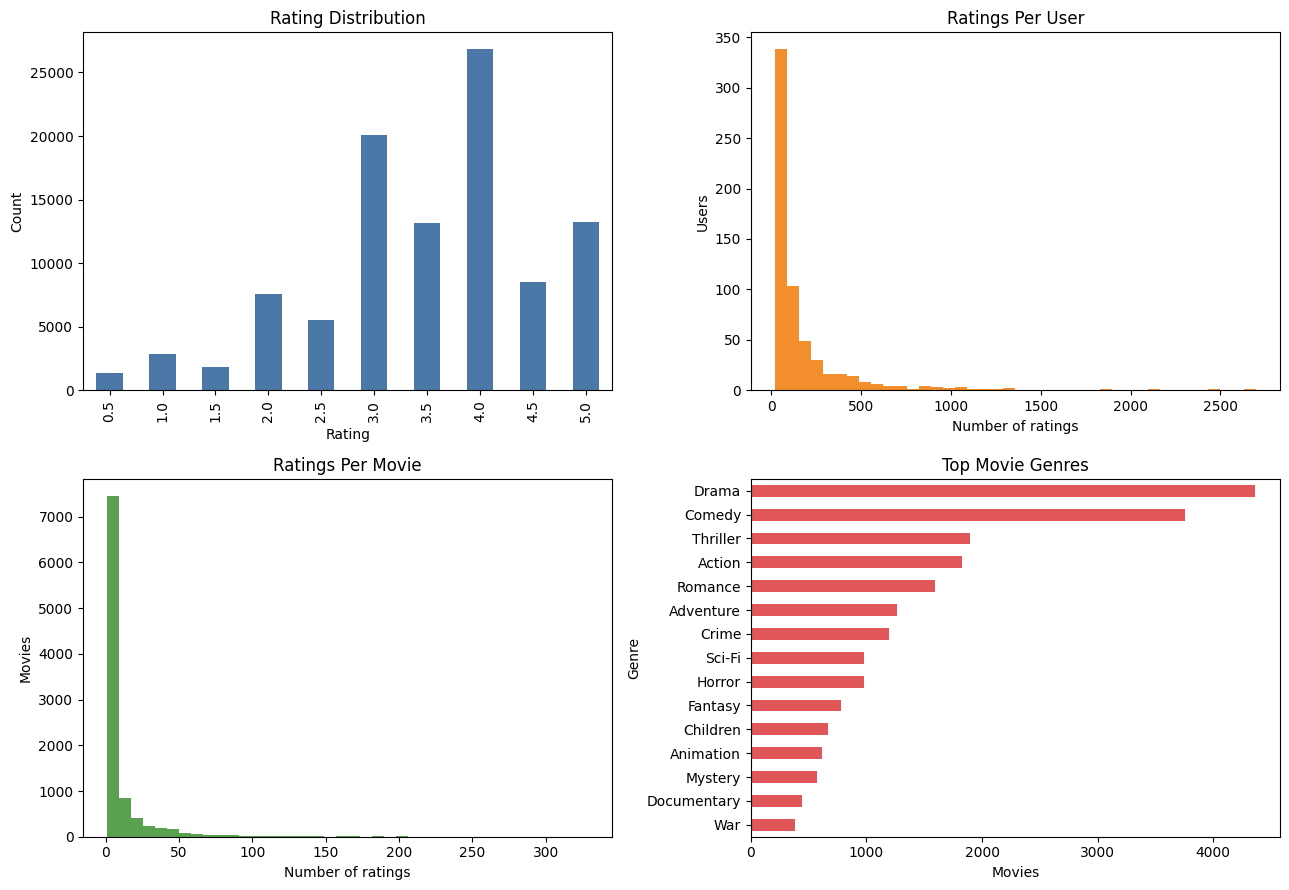

In [7]:
movie_genres = movies.copy()
movie_genres["genre_list"] = movie_genres["genres"].str.split("|")
genre_counts = (
    movie_genres.explode("genre_list")
    .query("genre_list != '(no genres listed)'")
    ["genre_list"]
    .value_counts()
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Rating Distribution")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Count")

ratings_per_user.plot(kind="hist", bins=40, ax=axes[0, 1], color="#F28E2B")
axes[0, 1].set_title("Ratings Per User")
axes[0, 1].set_xlabel("Number of ratings")
axes[0, 1].set_ylabel("Users")

ratings_per_movie.plot(kind="hist", bins=40, ax=axes[1, 0], color="#59A14F")
axes[1, 0].set_title("Ratings Per Movie")
axes[1, 0].set_xlabel("Number of ratings")
axes[1, 0].set_ylabel("Movies")

min(15, len(genre_counts))
genre_counts.head(15).sort_values().plot(kind="barh", ax=axes[1, 1], color="#E15759")
axes[1, 1].set_title("Top Movie Genres")
axes[1, 1].set_xlabel("Movies")
axes[1, 1].set_ylabel("Genre")

plt.tight_layout()

### 3.1 EDA Findings Used For Modeling

The EDA leads to several practical modeling decisions:

- The user-movie matrix is very sparse, so the system cannot rely on dense user histories for every user.
- Some movies receive many more ratings than others, which creates popularity bias but also makes popularity a strong baseline.
- User activity is uneven, so the system needs to handle both active users and users with limited rating history.
- Genre information is useful as a content signal, especially for users or movies with weaker collaborative information.
- Because the final product recommends ranked lists, evaluation should focus on top-K ranking metrics instead of only rating-prediction error.

## 4. Feature Engineering

The raw MovieLens data is not used directly by the final models. It is transformed into interaction, content, and ranking features that support collaborative filtering, neural collaborative filtering, hybrid ranking, and explainability.

The most important feature engineering steps are:

- converting Unix timestamps into datetime values
- multi-hot encoding movie genres
- merging rating interactions with movie metadata
- creating a temporal per-user train/test split
- defining positive interactions as ratings greater than or equal to 4.0
- sampling negative interactions for ranking models
- encoding user and movie identifiers for neural models
- preparing component scores for the final hybrid recommender

These transformations connect directly to the challenges found in the EDA. Because the user-movie matrix is sparse, the system needs both collaborative signals and metadata-based signals. Because the final product returns ranked recommendations, the training and evaluation data must be prepared around positive held-out items and candidate rankings.

In [8]:
# Timestamp and genre feature engineering
ratings_fe = ratings.copy()
ratings_fe["datetime"] = pd.to_datetime(ratings_fe["timestamp"], unit="s")

genre_dummies = movies["genres"].str.get_dummies(sep="|")
movies_with_genres = pd.concat([movies[["movieId", "title"]], genre_dummies], axis=1)

master_preview = ratings_fe.merge(movies_with_genres, on="movieId", how="left")
master_preview = master_preview.sort_values(["userId", "datetime"])

genre_cols = genre_dummies.columns.tolist()

feature_engineering_summary = pd.DataFrame(
    {
        "feature_group": [
            "datetime feature",
            "genre multi-hot features",
            "merged interaction-metadata table",
            "positive interaction label",
        ],
        "description": [
            "Unix timestamp converted to readable datetime for temporal splitting",
            f"{len(genre_cols)} binary genre columns created from movies.csv",
            f"ratings joined with movie title and genre features; shape={master_preview.shape}",
            "rating >= 4.0 is treated as relevant/positive for ranking",
        ],
    }
)

feature_engineering_summary

,feature_group,description
0,datetime feature,Unix timestamp converted to readable datetime ...
1,genre multi-hot features,20 binary genre columns created from movies.csv
2,merged interaction-metadata table,ratings joined with movie title and genre feat...
3,positive interaction label,rating >= 4.0 is treated as relevant/positive ...


In [9]:
# Temporal per-user split used by training and evaluation
split_df = master_preview.copy()
split_df["rank"] = split_df.groupby("userId").cumcount()
split_df["count"] = split_df.groupby("userId")["userId"].transform("count")

train_df = split_df[split_df["rank"] < split_df["count"] * 0.8].copy()
test_df = split_df[split_df["rank"] >= split_df["count"] * 0.8].copy()

positive_threshold = 4.0
train_positive = train_df[train_df["rating"] >= positive_threshold]
test_positive = test_df[test_df["rating"] >= positive_threshold]

split_summary = pd.DataFrame(
    {
        "metric": [
            "training interactions",
            "test interactions",
            "training positive interactions",
            "test positive interactions",
            "users in training split",
            "users with positive held-out test items",
            "unique movies in training split",
        ],
        "value": [
            len(train_df),
            len(test_df),
            len(train_positive),
            len(test_positive),
            train_df["userId"].nunique(),
            test_positive["userId"].nunique(),
            train_df["movieId"].nunique(),
        ],
    }
)

split_summary

,metric,value
0,training interactions,80896
1,test interactions,19940
2,training positive interactions,39348
3,test positive interactions,9232
4,users in training split,610
5,users with positive held-out test items,591
6,unique movies in training split,8246


In [10]:
# Ranking-model labels and negative sampling idea
# In full training, each positive interaction is paired with sampled unrated movies.
example_user = int(train_positive["userId"].iloc[0])
user_seen_movies = set(train_df.loc[train_df["userId"] == example_user, "movieId"])
all_movie_ids = set(master_preview["movieId"].unique())
negative_pool_size = len(all_movie_ids - user_seen_movies)

encoding_summary = pd.DataFrame(
    {
        "object": [
            "user encoder",
            "movie/item encoder",
            "positive label",
            "negative label",
            "example user's negative candidate pool",
        ],
        "purpose": [
            "maps raw userId values to contiguous integer indices for neural embeddings",
            "maps raw movieId values to contiguous integer indices for neural embeddings",
            "label 1 for rating >= 4.0",
            "label 0 for sampled movies the user has not rated",
            "unrated movies available for sampled negative training/evaluation",
        ],
        "value": [
            train_df["userId"].nunique(),
            train_df["movieId"].nunique(),
            "rating >= 4.0",
            "sampled unrated movie",
            negative_pool_size,
        ],
    }
)

encoding_summary

,object,purpose,value
0,user encoder,maps raw userId values to contiguous integer i...,610
1,movie/item encoder,maps raw movieId values to contiguous integer ...,8246
2,positive label,label 1 for rating >= 4.0,rating >= 4.0
3,negative label,label 0 for sampled movies the user has not rated,sampled unrated movie
4,example user's negative candidate pool,unrated movies available for sampled negative ...,9538


### 4.1 Feature Engineering Impact

The engineered features support different parts of the system:

- Genre multi-hot vectors allow content-based scoring, genre affinity, SHAP-style hybrid explanations, and neural side information.
- The temporal split prevents future interactions from leaking into training.
- Positive labels make the task ranking-oriented instead of pure rating prediction.
- Negative sampling gives the ranking NeuMF examples of movies that should be ranked below positive items.
- User and item encoders allow neural embedding layers to learn compact user/movie representations.
- Hybrid component scores make the final model explainable because each recommendation can be decomposed into item similarity, popularity, and genre match.

## 5. Modeling

The project compares several recommendation techniques, starting from simple baselines and moving toward more advanced collaborative, neural, and hybrid models. This is important because a recommender system should not be judged only against complex models. Simple baselines such as popularity often perform strongly, especially when the dataset is sparse.

The final system includes more than three modeling approaches:

1. random baseline
2. Bayesian-smoothed popularity baseline
3. genre-personalized popularity
4. item-item KNN collaborative filtering
5. original rating-prediction NeuMF
6. ranking NeuMF
7. hybrid ranker

The models are designed to answer slightly different questions. Popularity models are useful for cold-start or low-history situations. Item-item KNN uses collaborative behavior and gives direct explanations. NeuMF learns latent user and movie representations. The hybrid ranker combines collaborative, popularity, and genre signals into one final ranking model.

In [11]:
modeling_approaches = pd.DataFrame(
    [
        {
            "model": "random baseline",
            "technique": "random ranking",
            "main_signal": "none",
            "purpose": "sanity-check lower bound",
            "explainability": "not meaningful",
        },
        {
            "model": "Bayesian popularity",
            "technique": "popularity baseline with smoothing",
            "main_signal": "average rating adjusted by rating count",
            "purpose": "strong simple baseline and cold-start support",
            "explainability": "recommended because many users rated it highly",
        },
        {
            "model": "genre-personalized popularity",
            "technique": "content-aware popularity baseline",
            "main_signal": "popularity plus user genre profile",
            "purpose": "handles sparse histories better than pure collaborative filtering",
            "explainability": "recommended because it is popular and matches preferred genres",
        },
        {
            "model": "item-item KNN",
            "technique": "collaborative filtering with cosine similarity",
            "main_signal": "similarity to movies the user liked",
            "purpose": "strong explainable collaborative recommender",
            "explainability": "shows similar liked movies as evidence",
        },
        {
            "model": "rating NeuMF",
            "technique": "neural collaborative filtering for rating prediction",
            "main_signal": "user/item embeddings plus genre features",
            "purpose": "original neural model; useful comparison but not ideal for top-K ranking",
            "explainability": "limited; genre features can be inspected",
        },
        {
            "model": "ranking NeuMF",
            "technique": "neural collaborative filtering with sampled negatives",
            "main_signal": "learned relevance score from positive and negative interactions",
            "purpose": "strong neural top-K model",
            "explainability": "genre occlusion sensitivity, not direct embedding explanations",
        },
        {
            "model": "hybrid ranker",
            "technique": "weighted ensemble ranker",
            "main_signal": "item KNN + popularity + genre affinity",
            "purpose": "final GUI model with best balance of quality and interpretability",
            "explainability": "component contributions and similar liked movies",
        },
    ]
)
modeling_approaches

,model,technique,main_signal,purpose,explainability
0,random baseline,random ranking,none,sanity-check lower bound,not meaningful
1,Bayesian popularity,popularity baseline with smoothing,average rating adjusted by rating count,strong simple baseline and cold-start support,recommended because many users rated it highly
2,genre-personalized popularity,content-aware popularity baseline,popularity plus user genre profile,handles sparse histories better than pure coll...,recommended because it is popular and matches ...
3,item-item KNN,collaborative filtering with cosine similarity,similarity to movies the user liked,strong explainable collaborative recommender,shows similar liked movies as evidence
4,rating NeuMF,neural collaborative filtering for rating pred...,user/item embeddings plus genre features,original neural model; useful comparison but n...,limited; genre features can be inspected
5,ranking NeuMF,neural collaborative filtering with sampled ne...,learned relevance score from positive and nega...,strong neural top-K model,"genre occlusion sensitivity, not direct embedd..."
6,hybrid ranker,weighted ensemble ranker,item KNN + popularity + genre affinity,final GUI model with best balance of quality a...,component contributions and similar liked movies


### 5.1 From Baselines To Advanced Models

The modeling process followed a gradual strategy.

First, simple baselines were used to establish reference performance. The random baseline confirms that the evaluation pipeline works, while Bayesian popularity checks how much can be achieved by recommending generally reliable movies.

Second, collaborative filtering was introduced through item-item KNN. This model is especially useful for explainability because it can connect each recommendation to specific movies the user liked before.

Third, neural collaborative filtering was tested. The original NeuMF model predicted ratings, but this was not aligned with the final recommendation goal. Therefore, the final neural model was retrained as a ranking model using positive interactions and sampled negatives.

Finally, the hybrid ranker combines the strongest practical signals: collaborative similarity, popularity, and genre affinity. This makes it robust in sparse settings and easier to explain in the application.

In [12]:
hybrid_weights = pd.DataFrame(
    {
        "component": ["item-item KNN", "Bayesian popularity", "genre affinity"],
        "weight": [0.50, 0.25, 0.25],
        "role": [
            "captures similarity to movies the user liked",
            "keeps reliable/popular movies competitive",
            "supports content match and sparse-history users",
        ],
    }
)

print("Hybrid ranker scoring idea:")
print("final_score = 0.50 * item_knn_score + 0.25 * popularity_score + 0.25 * genre_score")
hybrid_weights

Hybrid ranker scoring idea:
final_score = 0.50 * item_knn_score + 0.25 * popularity_score + 0.25 * genre_score


,component,weight,role
0,item-item KNN,0.50,captures similarity to movies the user liked
1,Bayesian popularity,0.25,keeps reliable/popular movies competitive
2,genre affinity,0.25,supports content match and sparse-history users


### 5.2 Ranking NeuMF Training History

The original NeuMF was a rating-prediction model. The final NeuMF variant is trained as a ranking model with sampled negatives and `BCEWithLogitsLoss`, then evaluated with top-K metrics during training. The notebook displays the saved training history instead of retraining the model, so the final notebook remains fast and reproducible.

In [13]:
history_path = PROJECT_ROOT / "reports" / "neumf_ranking_training_history.csv"
history = pd.read_csv(history_path)
history.round(4)

,epoch,loss,precision@10,recall@10,hit_rate@10,ndcg@10,is_best
0,1,0.5845,0.148,0.1256,0.63,0.1755,True
1,2,0.4605,0.247,0.2502,0.80,0.3319,True
2,3,0.4189,0.341,0.3660,0.88,0.4566,True
3,4,0.3772,0.395,0.4405,0.89,0.5371,True
4,5,0.3376,0.423,0.5182,0.94,0.5914,True


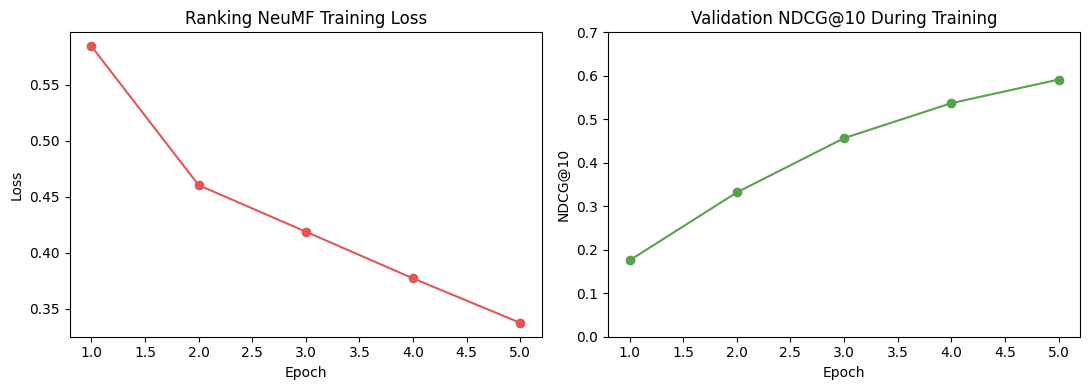

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history.plot(x="epoch", y="loss", marker="o", ax=axes[0], color="#E15759", legend=False)
axes[0].set_title("Ranking NeuMF Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

history.plot(x="epoch", y="ndcg@10", marker="o", ax=axes[1], color="#59A14F", legend=False)
axes[1].set_title("Validation NDCG@10 During Training")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("NDCG@10")
axes[1].set_ylim(0, max(0.7, history["ndcg@10"].max() + 0.05))
plt.tight_layout()

## 6. Evaluation

The final project is evaluated as a top-K recommendation task. This is different from ordinary rating prediction. In a real application, the system does not only need to predict a user's exact star rating; it needs to rank movies so that relevant titles appear near the top of the recommendation list.

The evaluation uses:

- temporal per-user train/test split
- held-out positives defined as `rating >= 4.0`
- 100 sampled unseen negative movies per evaluated user
- `K = 5` and `K = 10`
- primary metric: `NDCG@10`

The standard benchmark is `eval_topk`, and the final comparison is loaded from `reports/topk_evaluation_summary.csv`.

### 6.1 Evaluation Metrics

The main metrics are designed for ranked recommendation lists:

- `Precision@K`: how many of the top-K recommended movies are relevant
- `Recall@K`: how many of the user's relevant held-out movies are recovered in the top-K list
- `HitRate@K`: whether the top-K list contains at least one relevant movie
- `NDCG@K`: ranking quality that rewards placing relevant movies higher in the list

`NDCG@10` is the primary metric because the order of recommendations matters. A relevant movie at rank 1 is more useful than the same movie at rank 10.

In [15]:
metric_definitions = pd.DataFrame(
    [
        {
            "metric": "Precision@K",
            "question_answered": "Of the K recommended movies, how many were relevant?",
            "why_it_matters": "Measures recommendation list purity.",
        },
        {
            "metric": "Recall@K",
            "question_answered": "Of all relevant held-out movies, how many did we recover?",
            "why_it_matters": "Measures how much of the user's relevant future behavior was captured.",
        },
        {
            "metric": "HitRate@K",
            "question_answered": "Did the user receive at least one relevant recommendation?",
            "why_it_matters": "Useful for judging whether a recommendation list contains any success at all.",
        },
        {
            "metric": "NDCG@K",
            "question_answered": "Were relevant movies placed high in the ranking?",
            "why_it_matters": "Best matches the real top-of-list user experience.",
        },
    ]
)
metric_definitions

,metric,question_answered,why_it_matters
0,Precision@K,"Of the K recommended movies, how many were rel...",Measures recommendation list purity.
1,Recall@K,"Of all relevant held-out movies, how many did ...",Measures how much of the user's relevant futur...
2,HitRate@K,Did the user receive at least one relevant rec...,Useful for judging whether a recommendation li...
3,NDCG@K,Were relevant movies placed high in the ranking?,Best matches the real top-of-list user experie...


In [16]:
summary_path = PROJECT_ROOT / "reports" / "topk_evaluation_summary.csv"
summary = pd.read_csv(summary_path)
metric_cols = [col for col in summary.columns if col != "recommender"]
summary[metric_cols] = summary[metric_cols].round(4)

benchmark_table = summary.sort_values("ndcg@10", ascending=False).reset_index(drop=True)
benchmark_table

,recommender,precision@5,recall@5,hit_rate@5,ndcg@5,precision@10,recall@10,hit_rate@10,ndcg@10
0,hybrid_ranker,0.478,0.3386,0.90,0.5538,0.397,0.5041,0.95,0.5843
1,neumf_ranking_model,0.486,0.3015,0.87,0.5370,0.415,0.4846,0.91,0.5686
2,item_item_knn,0.448,0.3171,0.84,0.5016,0.382,0.4832,0.94,0.5409
3,popularity_bayes,0.398,0.2478,0.78,0.4575,0.330,0.3813,0.85,0.4731
4,genre_personalized_popularity,0.414,0.2833,0.86,0.4834,0.312,0.3726,0.88,0.4689
5,neumf_rating_model,0.182,0.1121,0.53,0.2047,0.187,0.2012,0.71,0.2389
6,random,0.108,0.0592,0.40,0.1210,0.104,0.1196,0.62,0.1359


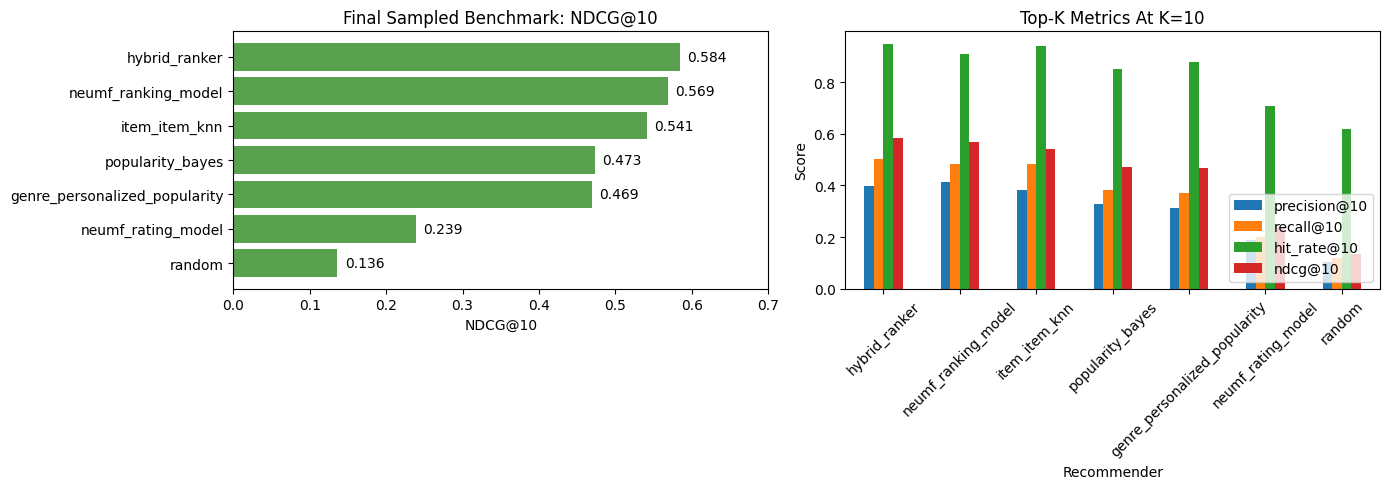

In [17]:
ranked_summary = summary.sort_values("ndcg@10", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(ranked_summary["recommender"], ranked_summary["ndcg@10"], color="#59A14F")
axes[0].set_title("Final Sampled Benchmark: NDCG@10")
axes[0].set_xlabel("NDCG@10")
axes[0].set_xlim(0, max(0.7, ranked_summary["ndcg@10"].max() + 0.05))
for index, value in enumerate(ranked_summary["ndcg@10"]):
    axes[0].text(value + 0.01, index, f"{value:.3f}", va="center")

comparison = summary.set_index("recommender")[["precision@10", "recall@10", "hit_rate@10", "ndcg@10"]]
comparison.loc[benchmark_table["recommender"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Top-K Metrics At K=10")
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Recommender")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(loc="lower right")

plt.tight_layout()

In [18]:
best_row = summary.sort_values("ndcg@10", ascending=False).iloc[0]
print(
    f"Best final sampled benchmark model: {best_row['recommender']} "
    f"with NDCG@10={best_row['ndcg@10']:.4f}."
)

neural_row = summary[summary["recommender"].eq("neumf_ranking_model")]
if not neural_row.empty:
    neural_row = neural_row.iloc[0]
    print(
        f"Best neural model: neumf_ranking_model with "
        f"NDCG@10={neural_row['ndcg@10']:.4f}."
    )

random_row = summary[summary["recommender"].eq("random")].iloc[0]
print(
    f"The best model improves over random by "
    f"{best_row['ndcg@10'] / random_row['ndcg@10']:.1f}x on NDCG@10."
)

Best final sampled benchmark model: hybrid_ranker with NDCG@10=0.5843.
Best neural model: neumf_ranking_model with NDCG@10=0.5686.
The best model improves over random by 4.3x on NDCG@10.


### 6.2 Top-K Relevance Confusion-Style Analysis

A traditional confusion matrix is not a perfect fit for recommender systems because the model outputs a ranked list rather than a binary class prediction for every possible user-movie pair. However, we can create a recommendation-specific confusion-style summary for the top-10 list.

For each evaluated user and model:

- recommended relevant items are analogous to true positives
- recommended non-relevant items are analogous to false positives
- relevant held-out items not recovered in the top 10 are analogous to false negatives

This table is approximate because it is reconstructed from aggregate top-K metrics, but it gives an intuitive view of how many useful recommendations appear in a typical top-10 list.

In [19]:
k = 10
confusion_style = summary[["recommender", "precision@10", "recall@10", "hit_rate@10", "ndcg@10"]].copy()
confusion_style["recommended_relevant_per_user"] = confusion_style["precision@10"] * k
confusion_style["recommended_not_relevant_per_user"] = k - confusion_style["recommended_relevant_per_user"]
confusion_style["estimated_relevant_items_per_user"] = np.where(
    confusion_style["recall@10"] > 0,
    confusion_style["recommended_relevant_per_user"] / confusion_style["recall@10"],
    np.nan,
)
confusion_style["estimated_missed_relevant_per_user"] = (
    confusion_style["estimated_relevant_items_per_user"]
    - confusion_style["recommended_relevant_per_user"]
)

confusion_style = confusion_style.sort_values("ndcg@10", ascending=False)
confusion_style[[
    "recommender",
    "recommended_relevant_per_user",
    "recommended_not_relevant_per_user",
    "estimated_missed_relevant_per_user",
    "hit_rate@10",
    "ndcg@10",
]].round(3)

,recommender,recommended_relevant_per_user,recommended_not_relevant_per_user,estimated_missed_relevant_per_user,hit_rate@10,ndcg@10
1,hybrid_ranker,3.97,6.03,3.905,0.95,0.584
3,neumf_ranking_model,4.15,5.85,4.414,0.91,0.569
2,item_item_knn,3.82,6.18,4.086,0.94,0.541
5,popularity_bayes,3.30,6.70,5.355,0.85,0.473
0,genre_personalized_popularity,3.12,6.88,5.254,0.88,0.469
4,neumf_rating_model,1.87,8.13,7.424,0.71,0.239
6,random,1.04,8.96,7.656,0.62,0.136


### 6.3 MLflow Tracking Artifacts

Final training and evaluation were logged with MLflow during project development. The local MLflow database can be opened with:

```powershell
python -m mlflow ui --backend-store-uri sqlite:///mlflow.db
```

For notebook reproducibility, this section does not query the MLflow database directly. Local MLflow SQLite databases can be version-sensitive: if the installed MLflow package expects a different schema, direct database queries may fail even though the saved project results are valid. Instead, the notebook verifies the saved MLflow artifact folders and displays the exported CSV reports that were logged during the final run.

In [20]:
mlruns_dir = PROJECT_ROOT / "mlruns"
training_artifacts = sorted(mlruns_dir.glob("2/*/artifacts/ranking_neumf"))
evaluation_artifacts = sorted(mlruns_dir.glob("3/*/artifacts/evaluation"))

mlflow_artifact_check = pd.DataFrame(
    [
        {
            "artifact_group": "ranking NeuMF training artifacts",
            "found": bool(training_artifacts),
            "example_path": str(training_artifacts[-1].relative_to(PROJECT_ROOT)) if training_artifacts else "not found",
        },
        {
            "artifact_group": "top-K evaluation artifacts",
            "found": bool(evaluation_artifacts),
            "example_path": str(evaluation_artifacts[-1].relative_to(PROJECT_ROOT)) if evaluation_artifacts else "not found",
        },
    ]
)
display(mlflow_artifact_check)

print("Final evaluation summary exported from the logged run:")
display(pd.read_csv(PROJECT_ROOT / "reports" / "topk_evaluation_summary.csv"))

leaderboard_path = PROJECT_ROOT / "reports" / "evaluation_runs" / "leaderboard.csv"
if leaderboard_path.exists():
    leaderboard = pd.read_csv(leaderboard_path)
    sort_col = "run_timestamp" if "run_timestamp" in leaderboard.columns else None
    if sort_col:
        leaderboard = leaderboard.sort_values(sort_col, ascending=False)
    display_cols = [
        col for col in [
            "run_id",
            "run_timestamp",
            "run_label",
            "recommender",
            "ndcg@10",
            "precision@10",
            "recall@10",
            "hit_rate@10",
        ]
        if col in leaderboard.columns
    ]
    display(leaderboard.head(10)[display_cols])
else:
    print("No leaderboard file found.")

,artifact_group,found,example_path
0,ranking NeuMF training artifacts,True,mlruns\2\d4870608b3e844e08e1053c7bb91bc6f\arti...
1,top-K evaluation artifacts,True,mlruns\3\b34aff93db674a5b81eecadde20d21a3\arti...


Final evaluation summary exported from the logged run:


,recommender,precision@5,recall@5,hit_rate@5,ndcg@5,precision@10,recall@10,hit_rate@10,ndcg@10
0,genre_personalized_popularity,0.414,0.283345,0.86,0.483428,0.312,0.372643,0.88,0.468950
1,hybrid_ranker,0.478,0.338605,0.90,0.553787,0.397,0.504098,0.95,0.584258
2,item_item_knn,0.448,0.317115,0.84,0.501596,0.382,0.483245,0.94,0.540862
3,neumf_ranking_model,0.486,0.301475,0.87,0.537005,0.415,0.484638,0.91,0.568627
4,neumf_rating_model,0.182,0.112126,0.53,0.204672,0.187,0.201209,0.71,0.238934
5,popularity_bayes,0.398,0.247829,0.78,0.457509,0.330,0.381300,0.85,0.473149
6,random,0.108,0.059232,0.40,0.120951,0.104,0.119565,0.62,0.135858


,run_id,run_timestamp,run_label,recommender,ndcg@10,precision@10,recall@10,hit_rate@10
64,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,random,0.135858,0.104,0.119565,0.62
63,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,popularity_bayes,0.473149,0.330,0.381300,0.85
62,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,neumf_rating_model,0.238934,0.187,0.201209,0.71
61,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,neumf_ranking_model,0.568627,0.415,0.484638,0.91
60,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,item_item_knn,0.540862,0.382,0.483245,0.94
59,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,hybrid_ranker,0.584258,0.397,0.504098,0.95
58,topk_sampled_100_negatives_20260609_174502,2026-06-09 17:45:02,NaN,genre_personalized_popularity,0.468950,0.312,0.372643,0.88
54,topk_final_mlflow_logged_sampled_100_negatives...,2026-06-04 20:47:41,final_mlflow_logged,neumf_ranking_model,0.568627,0.415,0.484638,0.91
51,topk_final_mlflow_logged_sampled_100_negatives...,2026-06-04 20:47:41,final_mlflow_logged,genre_personalized_popularity,0.468950,0.312,0.372643,0.88
52,topk_final_mlflow_logged_sampled_100_negatives...,2026-06-04 20:47:41,final_mlflow_logged,hybrid_ranker,0.584258,0.397,0.504098,0.95


## 7. Interpretability

Interpretability is treated as a core part of the recommender design, not as a separate visualization added after the model is finished. A movie recommendation is more useful when the user can understand why it appeared in the list. This is especially important for a GUI application, where explanations can increase user trust and make the recommendations feel less arbitrary.

The project uses model-specific explanations first. This is a deliberate decision: recommender systems often use latent user and item embeddings, but those embedding dimensions are not directly meaningful to humans. Instead of forcing explanations onto opaque features, the project prioritizes explanations that match how each model actually makes decisions.

### Item-Item KNN explanations

The item-item KNN model recommends movies by comparing candidate movies with movies the user has already liked. Its explanation is therefore direct: a movie is recommended because it is similar to specific movies in the user's positive history. This is useful for the live demo because it gives concrete evidence such as: "recommended because you liked these similar movies." The explanation is faithful to the model because the same similarity scores used for ranking are shown as evidence.

### Hybrid ranker explanations

The final Streamlit app uses the hybrid ranker. This model combines three interpretable signals:

- item-item KNN similarity: collaborative signal based on similar liked movies
- Bayesian-smoothed popularity: global quality and reliability signal
- genre affinity: content signal based on the user's preferred genres

The final recommendation score is a weighted combination of these components. This makes the explanation naturally decomposable: for every recommendation we can show how much came from item similarity, popularity, and genre match.

### Ranking NeuMF explanations

The ranking NeuMF model is useful as a strong neural benchmark, but its internal embeddings are not directly human-readable. For this reason, the notebook and application avoid presenting embedding dimensions as explanations. A safer model-specific explanation is genre occlusion sensitivity: we can estimate how the neural score changes when genre information is altered. This does not fully explain the latent collaborative embeddings, but it gives a reasonable sensitivity-based view of which content features influence the score.

### SHAP and LIME positioning

SHAP is most meaningful here when applied to structured, human-readable features. In this project, SHAP-style attribution is used for the final hybrid ranker's structured features: item KNN score, popularity score, and genre score. This avoids explaining latent neural embedding dimensions that do not have clear semantic meaning.

LIME was considered as a general local explanation technique, but the final implementation focuses on model-specific explanations and SHAP-style structured hybrid explanations. This is more appropriate for the project because the final hybrid model already has interpretable components and exact component contributions.

In [21]:
interpretability_methods = pd.DataFrame(
    [
        {
            "model_or_component": "item-item KNN",
            "explanation_method": "similar liked movies",
            "what_user_sees": "movies from their history that support the recommendation",
            "business_value": "easy to understand and increases trust",
        },
        {
            "model_or_component": "hybrid ranker",
            "explanation_method": "component contributions",
            "what_user_sees": "item similarity, popularity, and genre scores",
            "business_value": "shows whether a recommendation is personal, popular, or content-based",
        },
        {
            "model_or_component": "hybrid ranker",
            "explanation_method": "SHAP-style structured attribution",
            "what_user_sees": "attribution over item KNN, popularity, and genre features",
            "business_value": "adds local feature-level transparency without explaining opaque embeddings",
        },
        {
            "model_or_component": "ranking NeuMF",
            "explanation_method": "genre occlusion sensitivity",
            "what_user_sees": "how score changes when genre information is altered",
            "business_value": "gives limited neural insight while avoiding misleading embedding explanations",
        },
    ]
)
interpretability_methods

,model_or_component,explanation_method,what_user_sees,business_value
0,item-item KNN,similar liked movies,movies from their history that support the rec...,easy to understand and increases trust
1,hybrid ranker,component contributions,"item similarity, popularity, and genre scores","shows whether a recommendation is personal, po..."
2,hybrid ranker,SHAP-style structured attribution,"attribution over item KNN, popularity, and gen...",adds local feature-level transparency without ...
3,ranking NeuMF,genre occlusion sensitivity,how score changes when genre information is al...,gives limited neural insight while avoiding mi...


### 7.1 Explainable Recommendation Demo

The following cells demonstrate the explanation shown by the final hybrid recommender. The demo selects one user, displays a few movies from that user's positive history, and then generates top recommendations with explanation columns.

The most important fields are:

- `relevance_score`: final hybrid score
- `item_knn_score`: collaborative similarity to liked movies
- `popularity_score`: general popularity/reliability signal
- `genre_score`: match with the user's genre profile
- `explanation_summary`: short user-facing explanation sentence

This mirrors the explanation style used in the Streamlit app.

In [22]:
from src.hybrid_ranker import HybridRanker

ranker = HybridRanker(diversity_weight=0.05)
user_id = ranker.available_user_ids()[0]
liked = ranker.user_liked_movies(user_id, limit=5)
recommendations = ranker.recommend_for_user(user_id=user_id, top_n=5, diversity_weight=0.05)

print(f"Demo user: {user_id}")
print("Recently liked/high-rated movies used as evidence:")
display(liked)

cols = [
    "title",
    "genres",
    "relevance_score",
    "item_knn_score",
    "popularity_score",
    "genre_score",
    "explanation_summary",
]
display(recommendations[cols])

Demo user: 1
Recently liked/high-rated movies used as evidence:


,movieId,title,rating
0,2959,Fight Club (1999),5.0
1,2329,American History X (1998),5.0
2,954,Mr. Smith Goes to Washington (1939),5.0
3,2387,Very Bad Things (1998),5.0
4,1804,"Newton Boys, The (1998)",5.0


,title,genres,relevance_score,item_knn_score,popularity_score,genre_score,explanation_summary
0,For Your Eyes Only (1981),Action | Adventure | Thriller,0.8430,1.0000,0.5885,0.7836,Main signal: similarity to movies the user liked.
1,"Lord of the Rings: The Return of the King, The...",Action | Adventure | Drama | Fantasy,0.7839,0.6982,0.8680,0.8713,Main signal: similarity to movies the user liked.
2,"Spy Who Loved Me, The (1977)",Action | Adventure | Thriller,0.7871,0.8839,0.5968,0.7836,Main signal: similarity to movies the user liked.
3,Licence to Kill (1989),Action | Adventure | Thriller,0.7794,0.8944,0.5449,0.7836,Main signal: similarity to movies the user liked.
4,Austin Powers: The Spy Who Shagged Me (1999),Action | Adventure | Comedy,0.7617,0.8291,0.4970,0.8917,Main signal: similarity to movies the user liked.


In [23]:
first = recommendations.iloc[0]
print(f"Top recommendation: {first['title']}")
print(first["explanation_summary"])

print()
print("Similar liked movies that support this recommendation:")
for item in first["explanations"]:
    print(f"- {item['title']} (similarity={item['similarity']:.3f})")

print()
print("Hybrid component contributions:")
contributions = first["component_contributions"]
if isinstance(contributions, dict):
    contribution_rows = []
    for component, value in contributions.items():
        if isinstance(value, dict):
            row = {"component": component, **value}
        else:
            row = {"component": component, "value": value}
        contribution_rows.append(row)
    contribution_df = pd.DataFrame(contribution_rows)
else:
    contribution_df = pd.DataFrame(contributions)

display(contribution_df)

component_cols = ["item_knn_score", "popularity_score", "genre_score"]
dominant_signal = first[component_cols].astype(float).idxmax().replace("_score", "")

business_insight = pd.DataFrame(
    [
        {
            "insight": "dominant recommendation signal",
            "value": dominant_signal,
            "interpretation": "This explains whether the recommendation is mainly collaborative, popularity-driven, or genre-driven.",
        },
        {
            "insight": "user-facing trust evidence",
            "value": len(first["explanations"]),
            "interpretation": "Number of previously liked movies that can be shown as supporting evidence.",
        },
        {
            "insight": "application decision",
            "value": "hybrid ranker selected",
            "interpretation": "The final model balances accuracy with explanations that can be displayed in the GUI.",
        },
    ]
)

business_insight

Top recommendation: For Your Eyes Only (1981)
Main signal: similarity to movies the user liked.

Similar liked movies that support this recommendation:
- Thunderball (1965) (similarity=0.756)
- From Russia with Love (1963) (similarity=0.624)
- Dr. No (1962) (similarity=0.516)

Hybrid component contributions:


,component,item_knn,popularity,genre,value
0,contributions,0.5,0.147125,0.1959,NaN
1,total,NaN,NaN,NaN,0.843025
2,top_component,NaN,NaN,NaN,item_knn


,insight,value,interpretation
0,dominant recommendation signal,item_knn,This explains whether the recommendation is ma...
1,user-facing trust evidence,3,Number of previously liked movies that can be ...
2,application decision,hybrid ranker selected,The final model balances accuracy with explana...


### 7.2 Interpretability Findings

The interpretability analysis leads to three main findings:

- Explanations are strongest when they are tied directly to the model mechanism.
- The hybrid ranker is the best final application model because its score can be decomposed into understandable components.
- SHAP-style analysis is useful only when the explained features are meaningful, so it is applied to hybrid component scores rather than neural embedding dimensions.

From a user perspective, the best explanations are concrete: "this was recommended because it is similar to movies you liked" or "this matches your preferred genres." From a business perspective, these explanations make the recommender easier to trust, debug, and demonstrate.

## 8. Conclusions

This project successfully developed an explainable movie recommendation system using the MovieLens `latest-small` dataset. The goal was not only to produce accurate recommendations, but also to make the recommendation logic understandable for users. This is important because real streaming platforms rely on recommender systems to help users navigate very large catalogs, and explanations can make these recommendations more transparent and trustworthy.

### Key Findings

The main finding is that top-K ranking evaluation is more appropriate for this project than rating-prediction evaluation alone. The original rating-prediction NeuMF model was not well aligned with the final application goal, because the application needs ranked recommendation lists. After retraining NeuMF as a ranking model with positive interactions, sampled negatives, and `BCEWithLogitsLoss`, the neural model improved substantially.

The best final sampled benchmark model is the hybrid ranker. It achieved the strongest `NDCG@10` in the final comparison and was selected for the Streamlit application. The ranking NeuMF remains the strongest neural model, but the hybrid ranker provides the best balance between recommendation quality, robustness, and interpretability.

The EDA showed that the dataset is highly sparse, with users rating only a small fraction of available movies. This supports the decision to combine multiple signals instead of relying on only one technique. Popularity helps with sparse or cold-start-like situations, item-item KNN captures collaborative similarity, and genre features provide useful content information.

### Final Model Choice

The final application uses the hybrid ranker because it combines:

- item-item KNN similarity
- Bayesian-smoothed popularity
- genre affinity
- optional diversity reranking

This model is also the easiest to explain in a user-facing interface. Each recommendation can be connected to similar movies the user liked and decomposed into item similarity, popularity, and genre contribution scores.

### Limitations

The project still has several limitations:

- The main benchmark uses sampled negatives, which is efficient but less strict than ranking against the full catalog.
- Cold-start users are only partially addressed through popularity and genre signals.
- New movies with no interaction history remain difficult for collaborative filtering methods.
- Movie metadata is limited mostly to genres and tags; richer metadata such as plot summaries, cast, directors, or posters could improve content-based recommendations.
- The ranking NeuMF model is less directly interpretable than the hybrid model because it relies on latent embeddings.
- The current application focuses on recommendation quality and explanations, but could be improved visually with poster images and richer movie metadata.

### Future Work

The most important future improvements would be:

- evaluate models on a larger full-catalog benchmark
- add cold-start onboarding where new users select favorite movies or genres
- enrich movie features using tags, plot summaries, cast, directors, or text embeddings
- add poster images through IMDb/TMDB identifiers from `links.csv`
- expose ranking NeuMF as an optional comparison mode in the Streamlit app
- improve diversity beyond genre-based reranking
- add more detailed explanation quality evaluation

### Final Summary

Overall, the project demonstrates a complete recommendation workflow: data loading, validation, EDA, feature engineering, multiple modeling techniques, ranking evaluation, interpretability, MLflow artifact tracking, and a working Streamlit application. The final system is usable as a movie recommendation demo and shows how real-world recommender systems can combine accuracy with explainability.